# GPT-2 Lyrics Generation: Results and Discussion

This notebook analyses the dataset, training behaviour, test performance, generated lyrics, and evaluation scores for the baseline and fine-tuned GPT-2 models.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path('..')
processed = ROOT / 'data' / 'processed'
eval_dir = ROOT / 'results' / 'evaluation'
samples_dir = ROOT / 'results' / 'samples'
model_dir = ROOT / 'results' / 'training'

## 1. Dataset Statistics

The dataset was cleaned before training. Empty, duplicate, and very short lyrics were removed so that the model learned from more useful examples. The remaining songs were divided into three sets:

- **Training set:** used to update the model's parameters.
- **Validation set:** used during training to check performance on unseen lyrics and monitor overfitting.
- **Test set:** kept separate until the final evaluation to provide a fair comparison.

In [2]:
stats_path = processed / 'dataset_stats.json'
if stats_path.exists():
    stats = json.loads(stats_path.read_text(encoding='utf-8'))
    summary = pd.DataFrame({
        'Measure': ['CSV files', 'Raw songs', 'Cleaned songs', 'Removed songs', 'Training songs', 'Validation songs', 'Test songs'],
        'Value': [stats['csv_files'], stats['raw_rows'], stats['cleaned_rows'], stats['removed_rows'], stats['train_rows'], stats['validation_rows'], stats['test_rows']]
    })
    display(summary)
    removed_pct = 100 * stats['removed_rows'] / stats['raw_rows']
    display(Markdown(
        f"**Interpretation.** The original {stats['raw_rows']:,} rows were reduced to "
        f"{stats['cleaned_rows']:,} usable songs. Cleaning removed {stats['removed_rows']:,} rows "
        f"({removed_pct:.1f}%). The final split contains {stats['train_rows']:,} training, "
        f"{stats['validation_rows']:,} validation, and {stats['test_rows']:,} test songs."
    ))
    artist_counts = pd.Series(stats.get('artist_counts', {}), name='songs').sort_values(ascending=False)
    display(artist_counts.to_frame().head(10))
else:
    print('Run src/prepare_data.py first.')

,Measure,Value
0,CSV files,21
1,Raw songs,6027
2,Cleaned songs,5424
3,Removed songs,603
4,Training songs,4339
5,Validation songs,542
6,Test songs,543


**Interpretation.** The original 6,027 rows were reduced to 5,424 usable songs. Cleaning removed 603 rows (10.0%). The final split contains 4,339 training, 542 validation, and 543 test songs.

,songs
Eminem,499
Drake,444
Taylor Swift,435
Beyoncé,363
Rihanna,354
Lady Gaga,340
Justin Bieber,315
Coldplay,309
Nicki Minaj,293
Ariana Grande,277


## 2. Training and Validation Loss

**Loss** measures how incorrect the model's next-token predictions are. GPT-2 training uses causal language-model cross-entropy loss: for every token, the model predicts the token that should come next, and it receives a larger penalty when it gives the correct token a low probability.

- A **lower loss is better**.
- Loss is **not a percentage or accuracy score**.
- **Training loss** is measured on lyrics the model learns from.
- **Validation loss** is measured on unseen lyrics and is therefore a better indication of generalisation.

If training loss continues to fall while validation loss begins to rise, the model may be **overfitting**, meaning it is memorising the training data rather than learning patterns that transfer to unseen lyrics.

,epoch,step,train_loss,validation_loss,validation_perplexity
2,1,200,3.469993,3.186133,24.194674
3,2,400,3.243053,3.117249,22.584164
4,3,600,3.139474,3.089969,21.976388
5,3,800,3.104098,3.077058,21.694473


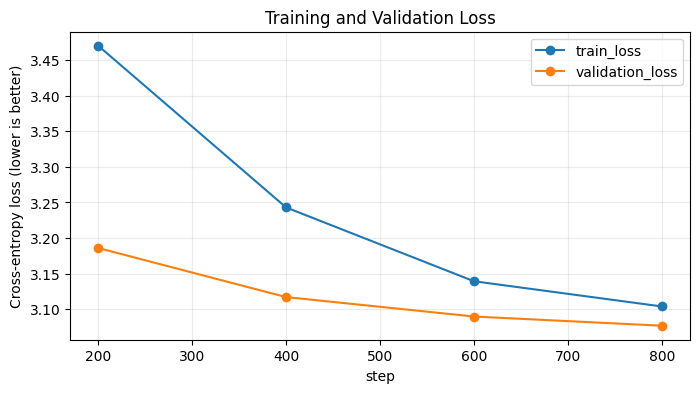

**Interpretation.** From step 200 to step 800, training loss fell from 3.470 to 3.104 (10.5% lower), while validation loss fell from 3.186 to 3.077 (3.4% lower). Because both curves decrease and validation loss does not turn upward, the recorded checkpoints show learning without clear evidence of overfitting.

In [3]:
log_path = model_dir / 'training_log.csv'
if log_path.exists():
    training_log_raw = pd.read_csv(log_path)
    # A restarted run can record the same step twice. Keep the latest record for a clear curve.
    training_log = (training_log_raw
                    .drop_duplicates(subset='step', keep='last')
                    .sort_values('step'))
    display(training_log)
    ax = training_log.plot(
        x='step', y=['train_loss', 'validation_loss'], marker='o',
        figsize=(8, 4), title='Training and Validation Loss'
    )
    ax.set_ylabel('Cross-entropy loss (lower is better)')
    ax.grid(alpha=0.25)
    plt.show()

    first = training_log.iloc[0]
    last = training_log.iloc[-1]
    train_change = 100 * (first['train_loss'] - last['train_loss']) / first['train_loss']
    val_change = 100 * (first['validation_loss'] - last['validation_loss']) / first['validation_loss']
    display(Markdown(
        f"**Interpretation.** From step {int(first['step'])} to step {int(last['step'])}, training loss fell "
        f"from {first['train_loss']:.3f} to {last['train_loss']:.3f} ({train_change:.1f}% lower), while "
        f"validation loss fell from {first['validation_loss']:.3f} to {last['validation_loss']:.3f} "
        f"({val_change:.1f}% lower). Because both curves decrease and validation loss does not turn upward, "
        f"the recorded checkpoints show learning without clear evidence of overfitting."
    ))
else:
    print('Training log not found yet.')

## 3. Test Loss and Perplexity

**Test loss** is the same prediction error described above, but it is calculated on the held-out test set after training. It estimates how well the final model handles lyrics that were not used to update it.

**Perplexity** is calculated as `exp(loss)`. It converts loss into a more intuitive scale. Roughly, a perplexity of 22 means that the model behaves as though it is choosing among about 22 plausible next-token options on average. This is an intuition, not a literal count at every token. A lower perplexity means the model is less uncertain and predicts the test lyrics better.

Perplexity measures token prediction, not complete songwriting quality. A model can achieve lower perplexity while still producing repetitive, incoherent, or unoriginal lyrics, so generated examples and qualitative ratings are also needed.

,model_type,examples,loss,perplexity
0,baseline,256,3.570,35.527
1,fine_tuned,256,3.105,22.302


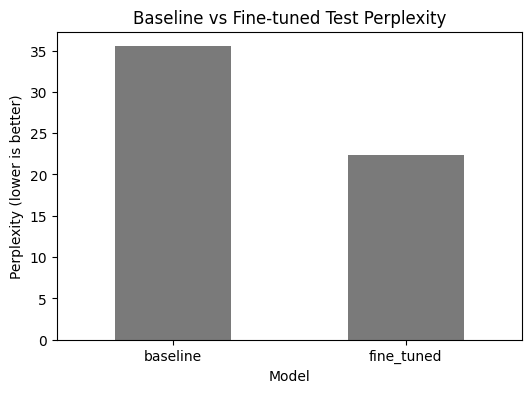

**Interpretation.** On 256 test examples, fine-tuning reduced loss from 3.570 to 3.105, a 13.0% reduction. Perplexity fell from 35.53 to 22.30, a 37.2% reduction. This is strong evidence that the fine-tuned model learned the language patterns of the lyrics dataset better than the original GPT-2 model.

In [4]:
ppl_path = eval_dir / 'perplexity_results.csv'
if ppl_path.exists():
    ppl = pd.read_csv(ppl_path)
    display(ppl[['model_type', 'examples', 'loss', 'perplexity']].round(3))

    ax = ppl.set_index('model_type')[['perplexity']].plot(
        kind='bar', legend=False, color=['#7a7a7a', '#2b78c5'], figsize=(6, 4),
        title='Baseline vs Fine-tuned Test Perplexity'
    )
    ax.set_ylabel('Perplexity (lower is better)')
    ax.set_xlabel('Model')
    ax.tick_params(axis='x', rotation=0)
    plt.show()

    baseline = ppl.loc[ppl['model_type'] == 'baseline'].iloc[0]
    fine_tuned = ppl.loc[ppl['model_type'] == 'fine_tuned'].iloc[0]
    loss_reduction = 100 * (baseline['loss'] - fine_tuned['loss']) / baseline['loss']
    ppl_reduction = 100 * (baseline['perplexity'] - fine_tuned['perplexity']) / baseline['perplexity']
    display(Markdown(
        f"**Interpretation.** On {int(fine_tuned['examples'])} test examples, fine-tuning reduced loss from "
        f"{baseline['loss']:.3f} to {fine_tuned['loss']:.3f}, a {loss_reduction:.1f}% reduction. "
        f"Perplexity fell from {baseline['perplexity']:.2f} to {fine_tuned['perplexity']:.2f}, "
        f"a {ppl_reduction:.1f}% reduction. This is strong evidence that the fine-tuned model learned the "
        f"language patterns of the lyrics dataset better than the original GPT-2 model."
    ))
else:
    print('Run src/evaluate.py after training.')

## 4. Generated Lyrics and Decoding Methods

The baseline and fine-tuned models were given the same prompts for a fair qualitative comparison. The fine-tuned model was also tested with several decoding methods:

- **Temperature:** controls randomness. A higher value increases variety but can reduce coherence; a lower value makes output safer and more predictable.
- **Top-k sampling:** at each step, the model samples only from the `k` most likely next tokens. This filters out very unlikely choices.
- **Top-p sampling:** samples from the smallest group of tokens whose combined probability reaches `p`. Its candidate set changes depending on how confident the model is.

Generated lyrics should be inspected for fluency, coherence, creativity, emotional tone, repetition, and whether they resemble song lyrics rather than ordinary prose.

In [5]:
sample_files = sorted(samples_dir.glob('generated_samples*.csv'), key=lambda p: p.stat().st_mtime)
if sample_files:
    samples = pd.read_csv(sample_files[-1])
    display(samples[['model_type', 'decoding', 'prompt', 'generated_text']].head(12))
    print(f'Displaying examples from: {sample_files[-1].name}')
else:
    print('Run src/generate.py after training.')

,model_type,decoding,prompt,generated_text
0,baseline,balanced_sampling,I miss the rain,"I miss the rain, but I know it will get better..."
1,baseline,balanced_sampling,A sad song about friendship,"A sad song about friendship, a bit like the ot..."
2,baseline,balanced_sampling,Dancing under city lights,"Dancing under city lights, but the men's voice..."
3,baseline,balanced_sampling,I found hope in the dark,"I found hope in the dark, but what really stoo..."
4,baseline,balanced_sampling,Goodbye but I still remember,Goodbye but I still remember what it was like....
5,baseline,balanced_sampling,A happy song about starting over,A happy song about starting over again? Or may...
6,fine_tuned,temperature,I miss the rain,I miss the rain and driveers up to my truck fo...
7,fine_tuned,temperature,A sad song about friendship,A sad song about friendship and the reality th...
8,fine_tuned,temperature,Dancing under city lights,Dancing under city lights as we gather outside...
9,fine_tuned,temperature,I found hope in the dark,I found hope in the dark things fade out but n...


Displaying examples from: generated_samples.csv


## 5. Qualitative Evaluation

Each output was scored from **1 (very poor) to 5 (excellent)** on five criteria:

- **Fluency:** grammatical and natural wording.
- **Coherence:** ideas connect logically across lines.
- **Creativity:** fresh imagery, wording, or concepts.
- **Emotional tone:** strength and consistency of the intended feeling.
- **Lyric-like quality:** whether the output feels suitable for a song.

The overall score below is the mean of these five criteria and is used only as a convenient summary. The individual criteria remain important because two outputs can receive the same overall score for different reasons.

,model_type,decoding,fluency,coherence,creativity,emotional_tone,lyric_like_quality,overall_score
2,fine_tuned,top_k,3.833,3.500,3.167,3.500,3.833,3.567
3,fine_tuned,top_p,2.667,2.667,3.000,2.667,3.167,2.834
1,fine_tuned,temperature,1.833,1.500,2.833,2.167,2.667,2.200
0,baseline,balanced_sampling,3.333,1.500,2.000,1.333,1.000,1.833


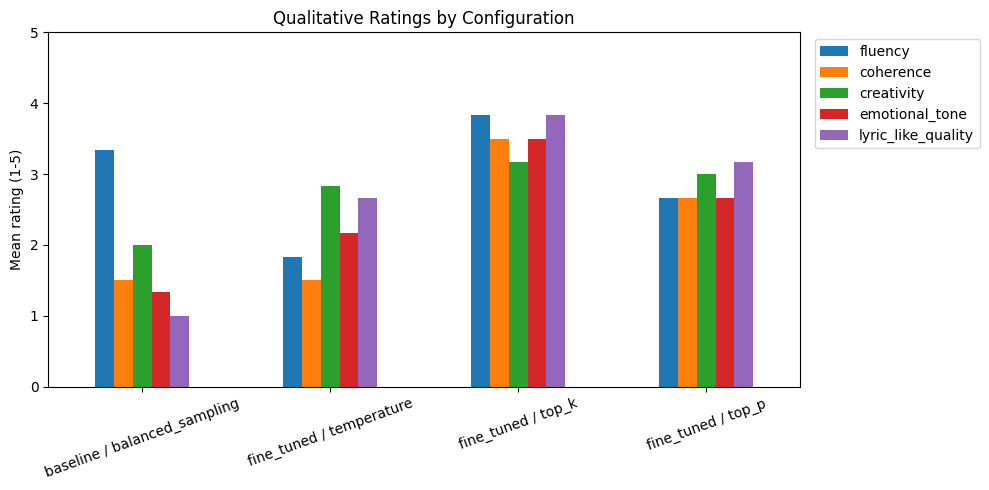

**Interpretation.** The best configuration was **fine_tuned with top_k sampling**, with an overall mean of 3.57/5, compared with 1.83/5 for the baseline. Top-k received the strongest scores for fluency, coherence, emotional tone, and lyric-like quality. Temperature sampling produced creative ideas but was less fluent and coherent, suggesting that its randomness was too high for consistent lyrics. Top-p was more balanced, but it did not perform as strongly as top-k.

In [6]:
human_path = eval_dir / 'human_eval_summary.csv'
if human_path.exists():
    human = pd.read_csv(human_path)
    rating_columns = ['fluency', 'coherence', 'creativity', 'emotional_tone', 'lyric_like_quality']
    human['overall_score'] = human[rating_columns].mean(axis=1)
    display(human.round(3).sort_values('overall_score', ascending=False))

    labels = human['model_type'] + ' / ' + human['decoding']
    plot_data = human.assign(configuration=labels).set_index('configuration')[rating_columns]
    ax = plot_data.plot(kind='bar', figsize=(10, 5), ylim=(0, 5), title='Qualitative Ratings by Configuration')
    ax.set_ylabel('Mean rating (1-5)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.show()

    best = human.loc[human['overall_score'].idxmax()]
    baseline_score = human.loc[human['model_type'] == 'baseline', 'overall_score'].iloc[0]
    display(Markdown(
        f"**Interpretation.** The best configuration was **{best['model_type']} with {best['decoding']} sampling**, "
        f"with an overall mean of {best['overall_score']:.2f}/5, compared with {baseline_score:.2f}/5 for the baseline. "
        f"Top-k received the strongest scores for fluency, coherence, emotional tone, and lyric-like quality. "
        f"Temperature sampling produced creative ideas but was less fluent and coherent, suggesting that its randomness "
        f"was too high for consistent lyrics. Top-p was more balanced, but it did not perform as strongly as top-k."
    ))
else:
    print('Fill results/evaluation/human_eval_scores.csv and rerun src/evaluate.py.')

## 6. Overall Conclusion

The quantitative and qualitative results both favour the fine-tuned GPT-2 model. Its lower test loss and perplexity show that it predicts lyric tokens more accurately than baseline GPT-2. The qualitative scores further show that decoding strategy matters: **top-k sampling produced the strongest overall lyrics**, while unrestricted temperature sampling traded consistency for creativity.

Therefore, the project demonstrates that fine-tuning GPT-2 on a domain-specific lyrics dataset improves its ability to generate song-like text. For the final demonstration, the fine-tuned model with top-k sampling is the recommended configuration.

## 7. Limitations

- The perplexity evaluation used 256 of the 543 test songs, so evaluating the full test set would provide a more complete estimate.
- The qualitative evaluation used six prompts per decoding configuration, which is a small sample.
- The current ratings were produced by one **AI composer-style evaluator**, not by a panel of human participants. They should be described as AI-assisted qualitative ratings unless group members independently replace them with their own scores.
- A single evaluator cannot measure agreement between raters. Future work should use several human raters and report average scores and inter-rater agreement.
- Lower perplexity does not guarantee originality, musicality, rhyme quality, or factual consistency.
- The training dataset is concentrated among a limited set of popular artists, so the model may reproduce their common themes and stylistic biases.